REGRESIÓN
|

In [14]:
%pip install ucimlrepo

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_percentage_error
from ucimlrepo import fetch_ucirepo
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop

In [16]:
import pandas as pd

dataset = fetch_ucirepo(id=235)
df = dataset.data.features.copy()

c:\Users\Natalia\Desktop\Universidad 7\Deep-Learning\2\.venv\lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Data check


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [18]:
# Change type to numeric
for col in ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month


C:\Users\Natalia\AppData\Local\Temp\ipykernel_21872\3346401150.py:6: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


Data cleaning

In [19]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
hour                         0
dayofweek                    0
month                        0
dtype: int64

In [20]:
df = df.ffill().dropna()

In [21]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
datetime                 0
hour                     0
dayofweek                0
month                    0
dtype: int64

In [ ]:
# Define target variable (y)
y = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]

# Define features (X) by dropping the target and non-numeric columns
X = df.drop(columns=['Date','Time','datetime','Sub_metering_1','Sub_metering_2','Sub_metering_3'])

print("X head")
display(X.head())
print("y head")
display(y.head())
print("X info")
X.info()
print("y info")
y.info()

X head


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,hour,dayofweek,month
0,4.216,0.418,234.84,18.4,17,5,12
1,5.360,0.436,233.63,23.0,17,5,12
2,5.374,0.498,233.29,23.0,17,5,12
3,5.388,0.502,233.74,23.0,17,5,12
4,3.666,0.528,235.68,15.8,17,5,12


y head


,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.0,1.0,17.0
1,0.0,1.0,16.0
2,0.0,2.0,17.0
3,0.0,1.0,17.0
4,0.0,1.0,17.0


X info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   hour                   int32  
 5   dayofweek              int32  
 6   month                  int32  
dtypes: float64(4), int32(3)
memory usage: 87.1 MB
y info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 3 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Sub_metering_1  float64
 1   Sub_metering_2  float64
 2   Sub_metering_3  float64
dtypes: float64(3)
memory usage: 47.5 MB


c:\Users\Natalia\Desktop\Universidad 7\Deep-Learning\2\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


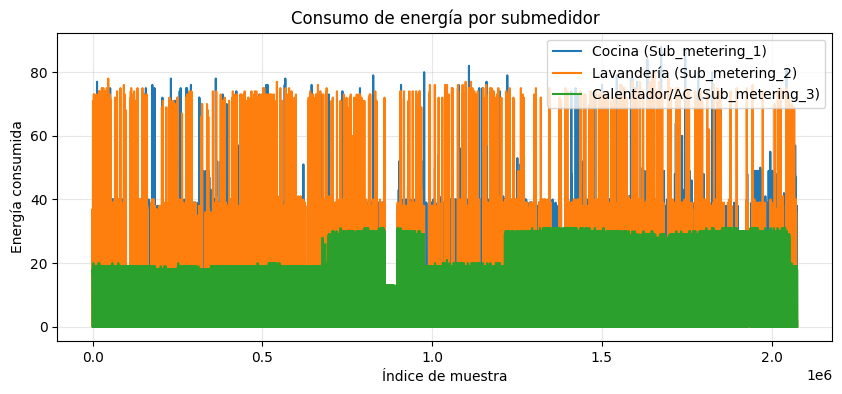

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(y['Sub_metering_1'], label='Cocina (Sub_metering_1)')
plt.plot(y['Sub_metering_2'], label='Lavandería (Sub_metering_2)')
plt.plot(y['Sub_metering_3'], label='Calentador/AC (Sub_metering_3)')

plt.title("Consumo de energía por submedidor")
plt.xlabel("Índice de muestra")
plt.ylabel("Energía consumida")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarizar características
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

In [25]:
model = Sequential([
    Dense(256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(3, activation='linear')
])

c:\Users\Natalia\Desktop\Universidad 7\Deep-Learning\2\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 17s 732us/step - loss: 19.8651 - val_loss: 18.7096
Epoch 2/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 799us/step - loss: 18.2038 - val_loss: 17.7783
Epoch 3/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 811us/step - loss: 17.6563 - val_loss: 17.7955
Epoch 4/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 812us/step - loss: 17.2792 - val_loss: 17.1196
Epoch 5/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 809us/step - loss: 16.9894 - val_loss: 17.1946
Epoch 6/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 811us/step - loss: 16.7517 - val_loss: 17.0007
Epoch 7/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 19s 815us/step - loss: 16.5512 - val_loss: 16.6890
Epoch 8/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 811us/step - loss: 16.3753 - val_loss: 16.4425
Epoch 9/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 18s 813us/step - loss: 16.2271 - val_loss: 16.4346
Epoch 10/100
22699/22699 ━━━━━━━━━━━━━━━━━━━━ 19s 816us/step - loss: 16.0877 - val_loss: 16.1329
Epoch 11/100
22699/22699 ━━━━━━━━━━━━━━

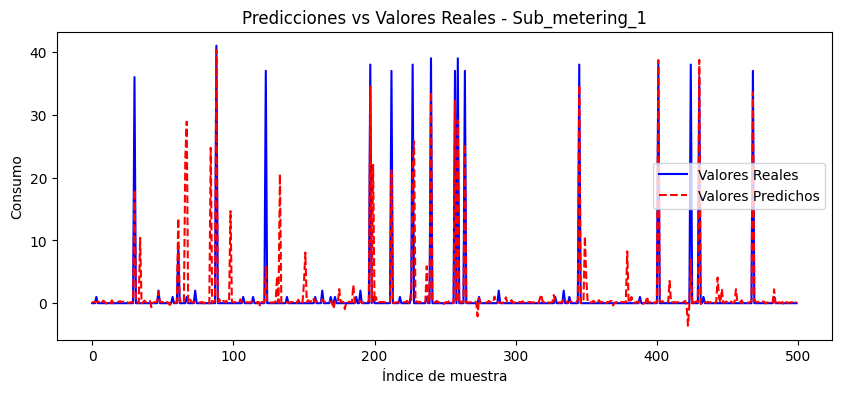

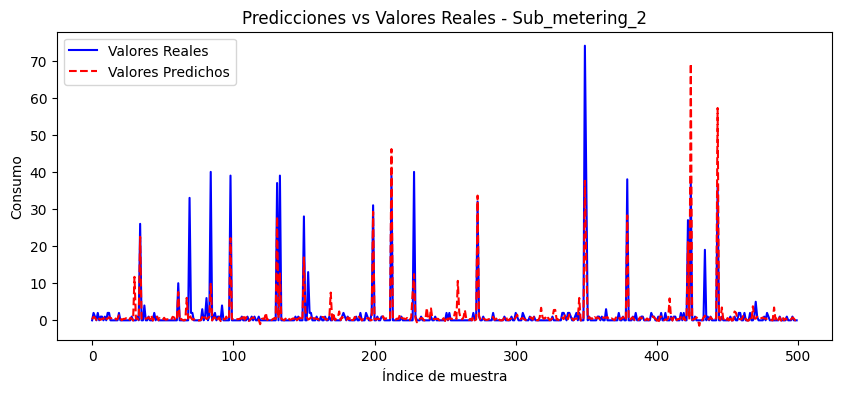

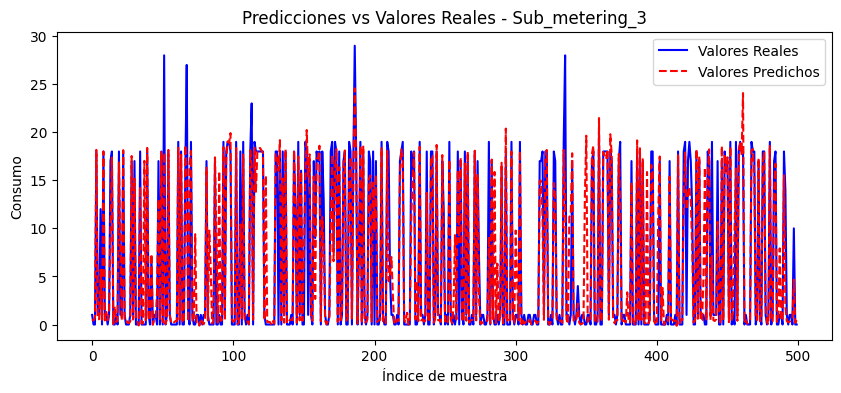

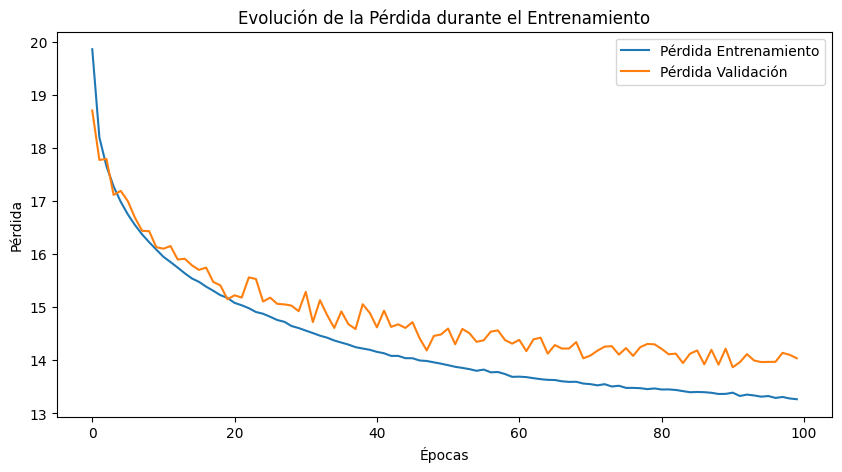

In [ ]:
# Compilar el modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='mse')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
 ]

# Entrenar el modelo usando validación separada
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluar la loss en test
test = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba: {test:.4f}")

# Predicciones
y_pred = model.predict(X_test)
y_test_np = y_test.to_numpy()


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2 por salida [Sub1, Sub2, Sub3]: {r2}")

# Graficar predicción vs real por cada salida
target_names = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
n_plot = 500

for i, name in enumerate(target_names):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_np[:n_plot, i], label='Valores Reales', color='blue')
    plt.plot(y_pred[:n_plot, i], label='Valores Predichos', color='red', linestyle='--')
    plt.title(f'Predicciones vs Valores Reales - {name}')
    plt.xlabel('Índice de muestra')
    plt.ylabel('Consumo')
    plt.legend()
    plt.show()

# Graficar evolución de la pérdida
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()